# Veri Bilimi Ara Ödev
**Türkiye Yapay Zeka Akademisi - Huawei Veri Bilimi ve Makine Öğrenmesi Bootcamp**

Bu notebook, ara ödev kapsamında verilen 15 soruyu sırasıyla çözmektedir. Veri setinin orijinal hali korunmuş, temizlik ve dönüşüm işlemleri kopya veri setleri üzerinde yapılmıştır.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('e_ticaret_veri_seti.csv')

In [4]:
df

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68
1,SIP100837,MUS1347,2025-03-17 21:13:00,Gaziantep,Güneydoğu Anadolu,Spor,Dambıl Seti,2,1475.15,0.10,29.9,Banka Kartı,VIP,4.0,1.0,Hayır,0.361,2685.17
2,SIP100050,MUS1066,2025-06-03 12:42:00,Kayseri,İç Anadolu,Kitap,İş Analitiği Rehberi,1,289.02,0.05,29.9,Kredi Kartı,Mevcut,6.0,2.0,Hayır,0.348,304.47
3,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80
4,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1423,SIP101093,MUS1187,2024-06-08 20:42:00,İstanbul,Marmara,Spor,Yoga Matı,1,772.23,0.00,29.9,Kredi Kartı,Mevcut,3.0,2.0,Hayır,0.275,802.13
1424,SIP101193,MUS1297,2025-11-06 08:17:00,Gaziantep,Güneydoğu Anadolu,Spor,Suluk,2,187.03,0.00,59.9,Kredi Kartı,Yeni,2.0,4.0,Evet,0.243,433.96
1425,SIP101210,MUS1122,2025-03-07 09:07:00,NaN,Marmara,Elektronik,Webcam,4,894.47,0.10,49.9,Kredi Kartı,Mevcut,3.0,5.0,Hayır,0.355,3269.99
1426,SIP101060,MUS1189,2025-04-19 21:52:00,Kocaeli,Marmara,Kitap,Veri Bilimi 101,2,248.55,0.05,59.9,banka karti,Yeni,4.0,3.0,Hayır,0.373,532.14


## Soru 1 — Veri setini yükleyin, ilk 10 ve son 10 satırı yazdırın

In [5]:
df.head(10)

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68
1,SIP100837,MUS1347,2025-03-17 21:13:00,Gaziantep,Güneydoğu Anadolu,Spor,Dambıl Seti,2,1475.15,0.10,29.9,Banka Kartı,VIP,4.0,1.0,Hayır,0.361,2685.17
2,SIP100050,MUS1066,2025-06-03 12:42:00,Kayseri,İç Anadolu,Kitap,İş Analitiği Rehberi,1,289.02,0.05,29.9,Kredi Kartı,Mevcut,6.0,2.0,Hayır,0.348,304.47
3,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80
4,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03
5,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,59.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.220,893.94
6,SIP101351,MUS1011,2025-02-27 11:35:00,İstanbul,Marmara,Ofis,Mouse Pad,3,169.47,0.05,29.9,Havale/EFT,VIP,3.0,2.0,Evet,0.382,512.89
7,SIP101172,MUS1357,2024-07-22 13:26:00,Ankara,İç Anadolu,Ofis,Mekanik Klavye,3,2344.47,0.00,59.9,Kredi Kartı,Mevcut,3.0,4.0,Hayır,0.312,7093.31
8,SIP100779,MUS1354,2025-12-05 11:19:00,İstanbul,Marmara,Kitap,Python Notları,4,219.14,0.00,29.9,Kredi Kartı,Yeni,18.0,5.0,Evet,0.408,906.46
9,SIP100202,MUS1067,2024-05-11 22:53:00,Bursa,Marmara,Kozmetik,Güneş Kremi,2,424.40,0.00,29.9,Havale/EFT,Mevcut,3.0,1.0,Hayır,0.212,878.70


In [6]:
df.tail(10)

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
1418,SIP100056,MUS1238,2024-04-19 20:27:00,Ankara,İç Anadolu,Kitap,Veri Bilimi 101,2,255.70,0.05,59.9,Kredi Kartı,Mevcut,3.0,2.0,Hayır,0.247,545.73
1419,SIP101279,MUS1149,2024-08-24 08:38:00,Ankara,İç Anadolu,Elektronik,Akıllı Saat,4,3074.80,0.15,39.9,Banka Kartı,Yeni,4.0,5.0,Hayır,0.414,10494.22
1420,SIP100920,MUS1425,2025-07-04 14:58:00,İzmir,Ege,Ev ve Yaşam,Masa Lambası,2,699.19,0.00,49.9,Banka Kartı,Yeni,2.0,4.0,Hayır,0.336,1448.28
1421,SIP100480,MUS1323,2024-06-20 20:34:00,Ankara,İç Anadolu,Elektronik,Kablosuz Kulaklık,1,1468.25,0.05,39.9,Banka Kartı,Mevcut,2.0,4.0,Hayır,0.275,1434.74
1422,SIP101222,MUS1440,2025-05-14 09:21:00,Bursa,Marmara,Spor,Dambıl Seti,1,1488.18,0.00,29.9,Kredi Kartı,Mevcut,3.0,4.0,Hayır,0.189,1518.08
1423,SIP101093,MUS1187,2024-06-08 20:42:00,İstanbul,Marmara,Spor,Yoga Matı,1,772.23,0.00,29.9,Kredi Kartı,Mevcut,3.0,2.0,Hayır,0.275,802.13
1424,SIP101193,MUS1297,2025-11-06 08:17:00,Gaziantep,Güneydoğu Anadolu,Spor,Suluk,2,187.03,0.00,59.9,Kredi Kartı,Yeni,2.0,4.0,Evet,0.243,433.96
1425,SIP101210,MUS1122,2025-03-07 09:07:00,NaN,Marmara,Elektronik,Webcam,4,894.47,0.10,49.9,Kredi Kartı,Mevcut,3.0,5.0,Hayır,0.355,3269.99
1426,SIP101060,MUS1189,2025-04-19 21:52:00,Kocaeli,Marmara,Kitap,Veri Bilimi 101,2,248.55,0.05,59.9,banka karti,Yeni,4.0,3.0,Hayır,0.373,532.14
1427,SIP100642,MUS1289,2024-09-22 16:36:00,Ankara,İç Anadolu,Kozmetik,Güneş Kremi,1,424.84,0.20,0.0,Dijital Cüzdan,Yeni,2.0,4.0,Hayır,0.317,339.87


**Yorum:** Veri seti, sipariş bazlı e-ticaret kayıtlarından oluşmaktadır. Her satır bir siparişi, sütunlar ise müşteri, ürün, fiyat, ödeme yöntemi ve teslimat bilgilerini temsil etmektedir. Örneğin, **MUS1238** kodlu müşteri 2024 yılında Ankara'ya bir kitap siparişi vermiş, ödemesini kredi kartı ile gerçekleştirmiş, siparişi 3 gün içinde teslim edilmiş ve ürünü iade etmemiştir.

## Soru 2 — Satır sayısı, sütun sayısı ve sütun isimleri

In [9]:
## Satır ve Sütun Sayısı
df.shape

(1428, 18)

In [10]:
## Sütun İsimleri

In [13]:
print(list(df.columns))

['siparis_id', 'musteri_id', 'siparis_tarihi', 'sehir', 'bolge', 'kategori', 'urun_adi', 'adet', 'birim_fiyat', 'indirim_orani', 'kargo_ucreti', 'odeme_turu', 'musteri_tipi', 'teslimat_gunu', 'musteri_puani', 'iade_durumu', 'kar_marji_orani', 'toplam_tutar']


**Yorum:** Veri seti 1428 satır ve 18 sütundan oluşuyor; sütunlar sipariş, müşteri, ürün ve finansal bilgileri kapsıyor.

## Soru 3 — info(), describe(), sayısal ve kategorik sütunlar

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1428 entries, 0 to 1427
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   siparis_id       1428 non-null   object 
 1   musteri_id       1428 non-null   object 
 2   siparis_tarihi   1428 non-null   object 
 3   sehir            1403 non-null   object 
 4   bolge            1428 non-null   object 
 5   kategori         1428 non-null   object 
 6   urun_adi         1428 non-null   object 
 7   adet             1428 non-null   int64  
 8   birim_fiyat      1428 non-null   float64
 9   indirim_orani    1412 non-null   float64
 10  kargo_ucreti     1428 non-null   float64
 11  odeme_turu       1393 non-null   object 
 12  musteri_tipi     1386 non-null   object 
 13  teslimat_gunu    1400 non-null   float64
 14  musteri_puani    1372 non-null   float64
 15  iade_durumu      1428 non-null   object 
 16  kar_marji_orani  1428 non-null   float64
 17  toplam_tutar  

In [15]:
df.describe()

,adet,birim_fiyat,indirim_orani,kargo_ucreti,teslimat_gunu,musteri_puani,kar_marji_orani,toplam_tutar
count,1428.000000,1428.000000,1412.000000,1428.000000,1400.000000,1372.000000,1428.000000,1428.000000
mean,2.136555,658.477654,0.052054,39.725140,3.370714,4.002187,0.302799,1370.590336
std,2.015770,1042.414639,0.060115,14.185017,1.825990,1.096707,0.069795,2961.689500
min,1.000000,93.110000,0.000000,0.000000,1.000000,0.000000,0.180000,89.680000
25%,1.000000,199.185000,0.000000,29.900000,2.000000,3.000000,0.244750,323.855000
50%,2.000000,287.120000,0.050000,39.900000,3.000000,4.000000,0.305000,669.135000
75%,3.000000,819.177500,0.100000,49.900000,4.000000,5.000000,0.362000,1390.950000
max,38.000000,18145.230000,0.200000,59.900000,31.000000,7.000000,0.420000,63870.200000


In [16]:
# Sayısal ve kategorik sütunların ayrılması
# sayısal: float64, int64
sayisal_sutunlar = df.select_dtypes(include=["int64", "float64"]).columns
sayisal_sutunlar

Index(['adet', 'birim_fiyat', 'indirim_orani', 'kargo_ucreti', 'teslimat_gunu',
       'musteri_puani', 'kar_marji_orani', 'toplam_tutar'],
      dtype='object')

In [17]:
#Sayısal ve kategorik sütunların ayrılması
# kategorikl: float64, int64
kategorik_sutunlar = df.select_dtypes(include=["object"]).columns
kategorik_sutunlar

Index(['siparis_id', 'musteri_id', 'siparis_tarihi', 'sehir', 'bolge',
       'kategori', 'urun_adi', 'odeme_turu', 'musteri_tipi', 'iade_durumu'],
      dtype='object')

**Yorum:** 8 sayısal, 10 kategorik (metin tipi) sütun bulunuyor. `siparis_tarihi` şu an metin (object) formatında olduğu için kategorik grupta görünüyor; bu sütunu Soru 8'de datetime tipine dönüştüreceğiz.

## Soru 4 — Eksik değer sayıları ve oranları

In [20]:
df.isnull().sum()

siparis_id          0
musteri_id          0
siparis_tarihi      0
sehir              25
bolge               0
kategori            0
urun_adi            0
adet                0
birim_fiyat         0
indirim_orani      16
kargo_ucreti        0
odeme_turu         35
musteri_tipi       42
teslimat_gunu      28
musteri_puani      56
iade_durumu         0
kar_marji_orani     0
toplam_tutar        0
dtype: int64

In [22]:
# eksik veri oranlarını hesapla
eksik_sayilari = df.isnull().sum()
eksik_oranlari = 100 * (eksik_sayilari / len(df))
print(eksik_oranlari)

siparis_id         0.000000
musteri_id         0.000000
siparis_tarihi     0.000000
sehir              1.750700
bolge              0.000000
kategori           0.000000
urun_adi           0.000000
adet               0.000000
birim_fiyat        0.000000
indirim_orani      1.120448
kargo_ucreti       0.000000
odeme_turu         2.450980
musteri_tipi       2.941176
teslimat_gunu      1.960784
musteri_puani      3.921569
iade_durumu        0.000000
kar_marji_orani    0.000000
toplam_tutar       0.000000
dtype: float64


In [25]:
print(eksik_oranlari.sort_values(ascending = False))

musteri_puani      3.921569
musteri_tipi       2.941176
odeme_turu         2.450980
teslimat_gunu      1.960784
sehir              1.750700
indirim_orani      1.120448
kargo_ucreti       0.000000
kar_marji_orani    0.000000
iade_durumu        0.000000
siparis_id         0.000000
musteri_id         0.000000
birim_fiyat        0.000000
adet               0.000000
urun_adi           0.000000
kategori           0.000000
bolge              0.000000
siparis_tarihi     0.000000
toplam_tutar       0.000000
dtype: float64


**Yorum:** En çok eksik veri `musteri_tipi`, `odeme_turu`, `teslimat_gunu`, `musteri_puani` ve `sehir` sütunlarında bulunuyor; ancak hiçbiri veri setinin %5'ini geçmiyor, bu yüzden satır silmek yerine doldurma (imputation) tercih edilecek.

In [28]:
# eksik veri içeren satırları incele
eksik_veri_olan_satirlar = df[df.isnull().any(axis = 1)]
eksik_veri_olan_satirlar.head(20)

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
19,SIP100677,MUS1148,2024-07-11 16:24:00,Adana,Akdeniz,Spor,Dambıl Seti,4,1517.65,0.00,29.9,Kapıda Ödeme,Mevcut,3.0,NaN,Hayır,0.311,6100.50
33,SIP101126,MUS1406,2024-09-11 20:05:00,Mersin,Akdeniz,Elektronik,Bluetooth Hoparlör,1,1159.89,0.10,39.9,Kredi Kartı,NaN,2.0,4.0,Hayır,0.204,1083.80
50,SIP101040,MUS1386,2025-04-01 09:30:00,Trabzon,Karadeniz,Spor,Dambıl Seti,1,1554.15,0.00,49.9,Banka Kartı,NaN,4.0,5.0,Hayır,0.217,1604.05
60,SIP100890,MUS1271,2024-11-07 19:47:00,İzmir,Ege,Kitap,Girişimcilik,4,216.38,NaN,49.9,Kredi Kartı,Yeni,1.0,3.0,Hayır,0.199,915.42
61,SIP101317,MUS1060,2024-09-05 20:49:00,NaN,Akdeniz,Ev ve Yaşam,Saklama Kutusu,1,233.63,0.10,29.9,Dijital Cüzdan,Yeni,5.0,2.0,Hayır,0.385,240.17
70,SIP100715,MUS1033,2024-11-10 21:50:00,İstanbul,Marmara,Ev ve Yaşam,Termos,1,552.05,0.00,39.9,NaN,Mevcut,2.0,3.0,Hayır,0.185,591.95
82,SIP100807,MUS1431,2025-01-07 14:12:00,Ankara,İç Anadolu,Kozmetik,Güneş Kremi,1,451.28,0.00,49.9,Kredi Kartı,NaN,4.0,5.0,Hayır,0.315,501.18
84,SIP100679,MUS1310,2024-05-20 18:51:00,İzmir,Ege,Ev ve Yaşam,Termos,2,477.62,0.00,49.9,Kredi Kartı,Mevcut,NaN,4.0,Hayır,0.323,1005.14
86,SIP101071,MUS1131,2024-09-18 12:24:00,NaN,İç Anadolu,Elektronik,Powerbank,1,816.74,0.00,39.9,Banka Kartı,Yeni,3.0,5.0,Hayır,0.301,856.64
92,SIP101366,MUS1347,2025-03-04 14:00:00,Bursa,Marmara,Ev ve Yaşam,Organizer,1,272.40,0.00,29.9,Kredi Kartı,Mevcut,1.0,NaN,Hayır,0.212,302.30


**Yorum:** Eksik değerler genellikle tek bir sütunda yoğunlaşıyor, birden fazla sütunda birden eksik veri olan satır sayısı azınlıkta; bu durum eksikliklerin rastgele (MCAR'a yakın) dağıldığını düşündürüyor.

## Soru 6 — indirim_orani ve musteri_puani eksiklerini medyan ile doldurma

In [37]:
df["indirim_orani"].isnull().sum()

16

In [38]:
df["musteri_puani"].isnull().sum()

56

In [41]:
# indirim oranı ve müşteri puanı eksik verilerini medyan ile doldurma
df_medyan = df.copy()
doldurulacak_sutunlar = ["indirim_orani", "musteri_puani"]
for sutun in doldurulacak_sutunlar:
  df_medyan[sutun] = df_medyan[sutun].fillna(df_medyan[sutun].median())
df_medyan[doldurulacak_sutunlar].isnull().sum()

indirim_orani    0
musteri_puani    0
dtype: int64

**Yorum:** Medyan, ortalamaya göre aykırı değerlerden daha az etkilendiği için sayısal sütunlardaki eksik verileri doldurmak amacıyla tercih edildi. Doldurma sonrası her iki sütunda da eksik değer kalmadı.

## Soru 7 — odeme_turu ve musteri_tipi eksiklerini mod ile doldurma

In [43]:
# indirim oranı ve müşteri puanı eksik verilerini mod ile doldurma
df_mod = df.copy()
# Doldurulacak sütunlar
doldurulacak_sutunlar = ["indirim_orani", "musteri_puani"]
# Doldurmadan önce eksik değer sayıları
print("Doldurmadan önce:")
print(df_mod[doldurulacak_sutunlar].isnull().sum())
# Mod ile doldurma
for sutun in doldurulacak_sutunlar:
    df_mod[sutun] = df_mod[sutun].fillna(df_mod[sutun].mode()[0])
# Doldurduktan sonra eksik değer sayıları
print("\nDoldurduktan sonra:")
print(df_mod[doldurulacak_sutunlar].isnull().sum())

Doldurmadan önce:
indirim_orani    16
musteri_puani    56
dtype: int64

Doldurduktan sonra:
indirim_orani    0
musteri_puani    0
dtype: int64


**Yorum:** Benzer işlem mod ile yapıldı. Burada bir liste return edileceğinden ötürü yanına [0] yazıldı.

## Soru 8 — siparis_tarihi datetime dönüşümü ve yeni tarih sütunları

In [44]:
# Sipariş tarihi sütununu datetime tipine dönüştürmek (string -> datetime)
df["siparis_tarihi"] = pd.to_datetime(df["siparis_tarihi"])
df["siparis_tarihi"].dtype

dtype('<M8[ns]')

In [45]:
df.dtypes

siparis_id                 object
musteri_id                 object
siparis_tarihi     datetime64[ns]
sehir                      object
bolge                      object
kategori                   object
urun_adi                   object
adet                        int64
birim_fiyat               float64
indirim_orani             float64
kargo_ucreti              float64
odeme_turu                 object
musteri_tipi               object
teslimat_gunu             float64
musteri_puani             float64
iade_durumu                object
kar_marji_orani           float64
toplam_tutar              float64
dtype: object

In [47]:
# Tarih sütunundan yeni özelliklerin üretilmesi
# zaman bazlı analizlerde yıl, ay, gün ve hafta günü bilgilerini üretiyoruz.
df["siparis_yili"] = df["siparis_tarihi"].dt.year
df["siparis_ayi"] = df["siparis_tarihi"].dt.month
df["siparis_gunu"] = df["siparis_tarihi"].dt.day
df["haftanin_gunu"] = df["siparis_tarihi"].dt.day_name()
df.head(10)

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100837,MUS1347,2025-03-17 21:13:00,Gaziantep,Güneydoğu Anadolu,Spor,Dambıl Seti,2,1475.15,0.10,...,VIP,4.0,1.0,Hayır,0.361,2685.17,2025,3,17,Monday
2,SIP100050,MUS1066,2025-06-03 12:42:00,Kayseri,İç Anadolu,Kitap,İş Analitiği Rehberi,1,289.02,0.05,...,Mevcut,6.0,2.0,Hayır,0.348,304.47,2025,6,3,Tuesday
3,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
4,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
5,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
6,SIP101351,MUS1011,2025-02-27 11:35:00,İstanbul,Marmara,Ofis,Mouse Pad,3,169.47,0.05,...,VIP,3.0,2.0,Evet,0.382,512.89,2025,2,27,Thursday
7,SIP101172,MUS1357,2024-07-22 13:26:00,Ankara,İç Anadolu,Ofis,Mekanik Klavye,3,2344.47,0.00,...,Mevcut,3.0,4.0,Hayır,0.312,7093.31,2024,7,22,Monday
8,SIP100779,MUS1354,2025-12-05 11:19:00,İstanbul,Marmara,Kitap,Python Notları,4,219.14,0.00,...,Yeni,18.0,5.0,Evet,0.408,906.46,2025,12,5,Friday
9,SIP100202,MUS1067,2024-05-11 22:53:00,Bursa,Marmara,Kozmetik,Güneş Kremi,2,424.40,0.00,...,Mevcut,3.0,1.0,Hayır,0.212,878.70,2024,5,11,Saturday


**Yorum:** `siparis_tarihi` artık gerçek bir datetime tipinde; bu sayede yıl, ay, gün ve haftanın günü gibi zaman bazlı özellikler türetilerek ileride mevsimsellik veya haftalık trend analizleri yapılabilir hale geldi.

## Soru 9 — Duplicate (tekrarlayan) kayıtların bulunması ve temizlenmesi

In [49]:
df.shape

(1428, 22)

In [50]:
tekrarlayan_kayitlar = df[df.duplicated()]
len(tekrarlayan_kayitlar)

28

In [51]:
## tekrarlayan kayıtları temizle
df = df.drop_duplicates()
df.shape

(1400, 22)

**Yorum:** Tespit edilen tekrarlayan kayıtlar veri setinden çıkarıldı; bu sayede aynı siparişin analizlerde birden fazla kez sayılması engellendi.

## Soru 10 — sehir sütununda tutarsız yazımların standartlaştırılması

In [52]:
df["sehir"].nunique()

19

In [53]:
# yardımcı fonksiyon: metinleri normalize edelim
# büyük küçük harf dönüşümleri, boşlukların kaldırılması, Türkçe karakter kaynaklı farkların düzenlenmesi
def metin_normalize_et(series):

  return(
      series.astype(str)
      .str.strip()
      .str.lower()
      .str.replace("i̇", "i", regex=False)
      .str.replace("ı", "i", regex=False)
      .str.replace("ö", "o", regex=False)
      .str.replace("ü", "u", regex=False)
      .str.replace("ç", "c", regex=False)
      .str.replace("ş", "s", regex=False)
      .str.replace("ğ", "g", regex=False)
  )

In [54]:
# şehir sütunundaki tutarsız değerleri düzeltme
df["sehir"] = metin_normalize_et(df["sehir"])
df["sehir"].unique()

C:\Users\YIGIT\AppData\Local\Temp\ipykernel_3440\2390653606.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sehir"] = metin_normalize_et(df["sehir"])


array(['istanbul', 'gaziantep', 'kayseri', 'antalya', 'konya', 'ankara',
       'bursa', 'trabzon', 'adana', 'mersin', 'kocaeli', 'izmir',
       'eskisehir', 'samsun', 'nan'], dtype=object)

In [55]:
sehir_duzeltme_haritasi = {
    "istanbul": "İstanbul",
    "ankara": "Ankara",
    "izmir": "İzmir",
    "antalya": "Antalya",
    "konya": "Konya",
    "bursa": "Bursa",
    "adana": "Adana",
    "gaziantep": "Gaziantep",
    "mersin": "Mersin",
    "kayseri": "Kayseri",
    "eskisehir": "Eskişehir",
    "samsun": "Samsun",
    "trabzon": "Trabzon",
    "kocaeli": "Kocaeli"
}

In [56]:
df["sehir"] = df["sehir"].replace(sehir_duzeltme_haritasi)
df["sehir"].unique()

C:\Users\YIGIT\AppData\Local\Temp\ipykernel_3440\2198393320.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sehir"] = df["sehir"].replace(sehir_duzeltme_haritasi)


array(['İstanbul', 'Gaziantep', 'Kayseri', 'Antalya', 'Konya', 'Ankara',
       'Bursa', 'Trabzon', 'Adana', 'Mersin', 'Kocaeli', 'İzmir',
       'Eskişehir', 'Samsun', 'nan'], dtype=object)

In [57]:
df["sehir"].nunique()

15

**Yorum:** `İstanbul / istanbul / Istanbul` gibi farklı yazımlar tek bir standart forma indirgendi; benzersiz şehir sayısı 19'dan 15'e düştü. Bu, şehir bazlı analizlerin (örn. gruplama, sayma) doğru sonuç vermesi için gereklidir.

## Soru 11 — kategori sütunundaki tutarsız değerlerin standartlaştırılması

In [58]:
# kategori sütunundaki tutarsız değerleri düzeltme
df["kategori"] = metin_normalize_et(df["kategori"])
df["kategori"].unique()

C:\Users\YIGIT\AppData\Local\Temp\ipykernel_3440\2672484380.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["kategori"] = metin_normalize_et(df["kategori"])


array(['kozmetik', 'spor', 'kitap', 'elektronik', 'ofis', 'ev ve yasam',
       'ev&yasam'], dtype=object)

In [59]:
kategori_duzeltme_haritasi = {
    "elektronik": "Elektronik",
    "kitap": "Kitap",
    "kozmetik": "Kozmetik",
    "kozmetık": "Kozmetik",
    "spor": "Spor",
    "ev yasam": "Ev Yaşam",
    "ev ve yasam": "Ev Yaşam",
    "ev&yasam": "Ev Yaşam",
    "ofis": "Ofis"
}
df["kategori"] = df["kategori"].replace(kategori_duzeltme_haritasi)
df["kategori"].unique()

C:\Users\YIGIT\AppData\Local\Temp\ipykernel_3440\1985694700.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["kategori"] = df["kategori"].replace(kategori_duzeltme_haritasi)


array(['Kozmetik', 'Spor', 'Kitap', 'Elektronik', 'Ofis', 'Ev Yaşam'],
      dtype=object)

In [60]:
## ödeme türü sütunundaki tutarsız değerleri düzeltelim
df["odeme_turu"] = metin_normalize_et(df["odeme_turu"])
df["odeme_turu"].unique()

C:\Users\YIGIT\AppData\Local\Temp\ipykernel_3440\3455216138.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["odeme_turu"] = metin_normalize_et(df["odeme_turu"])


array(['kredi karti', 'banka karti', 'kapida odeme', 'dijital cuzdan',
       'havale/eft', 'nan', 'kart', 'eft', 'havale'], dtype=object)

In [61]:
odeme_turu_duzeltme_haritasi = {
    "kredi karti": "Kredi Kartı",
    "kart": "Kredi Kartı",
    "banka karti": "Banka Kartı",
    "dijital cuzdan": "Dijital Cüzdan",
    "kapida odeme": "Kapıda Ödeme",
    "havale": "Havale/EFT",
    "eft": "Havale/EFT",
    "havale/eft": "Havale/EFT"
}
df["odeme_turu"] = df["odeme_turu"].replace(odeme_turu_duzeltme_haritasi)
df["odeme_turu"].unique()

C:\Users\YIGIT\AppData\Local\Temp\ipykernel_3440\3581851025.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["odeme_turu"] = df["odeme_turu"].replace(odeme_turu_duzeltme_haritasi)


array(['Kredi Kartı', 'Banka Kartı', 'Kapıda Ödeme', 'Dijital Cüzdan',
       'Havale/EFT', 'nan'], dtype=object)

In [62]:
# müşteri tipi sütunundaki tutarsız değerleri düzeltelim
df["musteri_tipi"] = metin_normalize_et(df["musteri_tipi"])
df["musteri_tipi"].unique()

C:\Users\YIGIT\AppData\Local\Temp\ipykernel_3440\4287139951.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["musteri_tipi"] = metin_normalize_et(df["musteri_tipi"])


array(['yeni', 'vip', 'mevcut', 'nan'], dtype=object)

In [63]:
musteri_tipi_duzeltme_haritasi = {
    "mevcut": "Mevcut",
    "yeni": "Yeni",
    "vip": "VIP"
}
df["musteri_tipi"] = df["musteri_tipi"].replace(musteri_tipi_duzeltme_haritasi)
df["musteri_tipi"].unique()

C:\Users\YIGIT\AppData\Local\Temp\ipykernel_3440\2656334692.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["musteri_tipi"] = df["musteri_tipi"].replace(musteri_tipi_duzeltme_haritasi)


array(['Yeni', 'VIP', 'Mevcut', 'nan'], dtype=object)

In [64]:
df["musteri_tipi"].value_counts()

musteri_tipi
Mevcut    674
Yeni      520
VIP       164
nan        42
Name: count, dtype: int64

**Yorum:** `Ev Yaşam / ev yaşam / Ev&Yaşam` gibi farklı yazım biçimleri tek bir kategori altında birleştirildi. Standartlaştırma sonrası her kategori artık tek bir isimle temsil ediliyor ve `value_counts()` çıktısı gerçek dağılımı doğru yansıtıyor.

## Soru 12 — Mantıksal olarak hatalı kayıtların tespiti ve çıkarılması

In [65]:
# mantıksal olarak hatalı kayıtları inceleme
# negatif yada anlamsız değerler bazı kayıtlarda veri kalitesini düşürebilir
hatali_kayitlar = df[
    (df["toplam_tutar"] <= 0) |
    (df["birim_fiyat"] <= 0) |
    (df["teslimat_gunu"] < 0) |
    (df["musteri_puani"] < 0) |
    (df["musteri_puani"] > 5)
]
len(hatali_kayitlar)

2

In [66]:
pd.set_option("display.max_columns", None)
hatali_kayitlar

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
609,SIP100095,MUS1165,2025-10-12 21:31:00,İstanbul,Marmara,Kozmetik,Şampuan,2,190.17,0.10,0.0,Dijital Cüzdan,Mevcut,3.0,6.0,Hayır,0.416,342.31,2025,10,12,Sunday
1008,SIP101290,MUS1225,2024-01-16 21:46:00,Kocaeli,Marmara,Kozmetik,Yüz Temizleme Jeli,2,303.82,0.05,29.9,Kredi Kartı,Yeni,5.0,7.0,Evet,0.287,607.16,2024,1,16,Tuesday


In [67]:
# mantıksal hataları temizleyelim
df = df[
    (df["toplam_tutar"] > 0) &
    (df["birim_fiyat"] > 0) &
    (df["teslimat_gunu"] >= 0) &
    (df["musteri_puani"] >= 0) &
    (df["musteri_puani"] <= 5)
]
df.shape

(1314, 22)

**Yorum:** Negatif/sıfır fiyat, negatif teslimat süresi veya 5 üzerinden verilen puanın 5'i aşması gibi durumlar veri girişi hatası olarak değerlendirildi ve bu kayıtlar veri setinden çıkarıldı.

In [69]:
# 4. IQR ile aykırı değer sınırlarını hesaplama
aykiri_sinirlar = {}

df_birim_fiyat = ["birim_fiyat"]

for sutun in df_birim_fiyat:

  q1 = df[sutun].quantile(0.25)
  q3 = df[sutun].quantile(0.75)

  iqr = q3 - q1
  alt_sinir = q1 - 1.5 * iqr
  ust_sinir = q3 + 1.5 * iqr

  aykiri_sinirlar[sutun] = {
      "q1": q1,
      "q3": q3,
      "iqr": iqr,
      "alt_sinir": alt_sinir,
      "ust_sinir": ust_sinir
  }
     

In [70]:
aykiri_sinirlar

{'birim_fiyat': {'q1': 199.07500000000002,
  'q3': 827.3975,
  'iqr': 628.3225,
  'alt_sinir': -743.4087499999999,
  'ust_sinir': 1769.88125}}

In [71]:
# aykırı değer içeren kayıtları tespit et
aykiri_maskesi = pd.Series(False, index = df.index)

for sutun in df_birim_fiyat:
  alt_sinir = aykiri_sinirlar[sutun]["alt_sinir"]
  ust_sinir = aykiri_sinirlar[sutun]["ust_sinir"]

  sutun_maskesi = (df[sutun] < alt_sinir) | (df[sutun] > ust_sinir)
  aykiri_maskesi = aykiri_maskesi | sutun_maskesi

In [72]:
# aykırı değer içeren kayıtları veri setinden temizleme
df_temiz = df[~aykiri_maskesi].copy()
df_temiz.shape

(1225, 22)

**Yorum:** IQR yöntemine göre alt ve üst sınırların dışında kalan `birim_fiyat` değerleri aykırı (outlier) olarak işaretlendi. Bu kayıtlar genellikle çok yüksek fiyatlı ürünleri (örn. elektronik) temsil ediyor olabilir.

## Soru 14 — toplam_tutar için histogram ve box plot

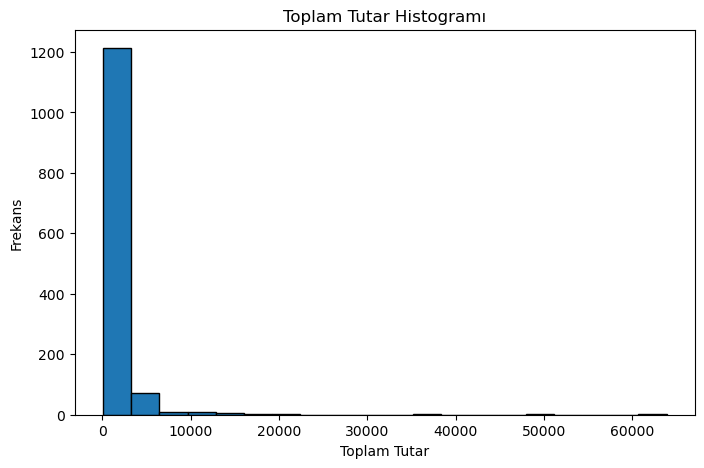

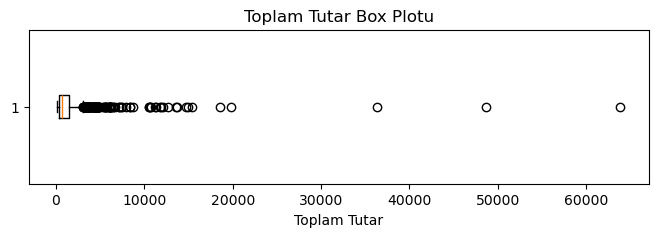

In [76]:
import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(df["toplam_tutar"], bins=20, edgecolor="black")
plt.title("Toplam Tutar Histogramı")
plt.xlabel("Toplam Tutar")
plt.ylabel("Frekans")
plt.show()

# Box Plot
plt.figure(figsize=(8, 2))
plt.boxplot(df["toplam_tutar"], vert=False)
plt.title("Toplam Tutar Box Plotu")
plt.xlabel("Toplam Tutar")
plt.show()

**Yorum:** Histogram, `toplam_tutar` dağılımının sağa çarpık (right-skewed) olduğunu gösteriyor; çoğu sipariş düşük-orta tutarlarda yoğunlaşırken az sayıda yüksek tutarlı sipariş kuyruğu uzatıyor. Box plot da bu yüksek tutarlı siparişleri üst sınırın dışında aykırı değerler olarak ortaya koyuyor.

Kategori Frekansları:
kategori
Kitap         237
Elektronik    234
Spor          219
Ofis          212
Kozmetik      210
Ev Yaşam      202
Name: count, dtype: int64
--------------------------------------------------
Müşteri Tipi Yüzde Dağılımı:
musteri_tipi
Mevcut    47.945205
Yeni      37.595129
VIP       11.491629
nan        2.968037
Name: proportion, dtype: float64
--------------------------------------------------


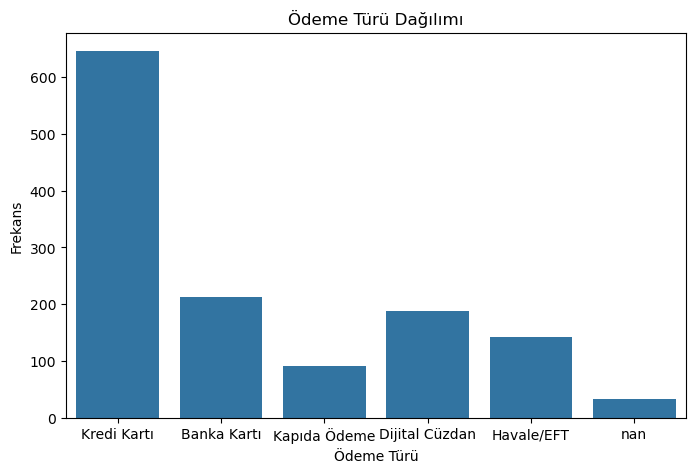

Temel İstatistikler:
        birim_fiyat  toplam_tutar  musteri_puani
count   1314.000000   1314.000000    1314.000000
mean     671.125038   1386.674932       3.988584
std     1076.378588   3022.918771       1.097955
min       93.660000     89.680000       0.000000
25%      199.075000    327.190000       3.000000
50%      287.735000    666.535000       4.000000
75%      827.397500   1431.890000       5.000000
max    18145.230000  63870.200000       5.000000
--------------------------------------------------
Kategori Bazında Ortalama Toplam Tutar:
kategori
Elektronik    3215.226752
Ev Yaşam       874.483119
Kitap          573.790127
Kozmetik       922.364857
Ofis          1313.416698
Spor          1301.155205
Name: toplam_tutar, dtype: float64

En yüksek ortalama toplam_tutar değerine sahip kategori:
Elektronik -> 3215.2267521367517
--------------------------------------------------
Müşteri Tipine Göre Ortalama Müşteri Puanı:
musteri_tipi
Mevcut    4.007937
VIP       3.894040
Yeni      

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. kategori sütunu için frekanslar
print("Kategori Frekansları:")
print(df["kategori"].value_counts())

print("-" * 50)

# 2. musteri_tipi sütunu için yüzde dağılımı
print("Müşteri Tipi Yüzde Dağılımı:")
print(df["musteri_tipi"].value_counts(normalize=True) * 100)

print("-" * 50)

# 3. odeme_turu sütunu için Count Plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="odeme_turu")
plt.title("Ödeme Türü Dağılımı")
plt.xlabel("Ödeme Türü")
plt.ylabel("Frekans")
plt.show()

# 4. Sayısal sütunların temel istatistikleri
print("Temel İstatistikler:")
print(df[["birim_fiyat", "toplam_tutar", "musteri_puani"]].describe())

print("-" * 50)

# 5. Kategori bazında ortalama toplam_tutar
kategori_ort = df.groupby("kategori")["toplam_tutar"].mean()
print("Kategori Bazında Ortalama Toplam Tutar:")
print(kategori_ort)

print("\nEn yüksek ortalama toplam_tutar değerine sahip kategori:")
print(kategori_ort.idxmax(), "->", kategori_ort.max())

print("-" * 50)

# 6. Müşteri tipi bazında ortalama müşteri puanı
musteri_ort = df.groupby("musteri_tipi")["musteri_puani"].mean()
print("Müşteri Tipine Göre Ortalama Müşteri Puanı:")
print(musteri_ort)

print("\nEn yüksek ortalama müşteri puanına sahip müşteri tipi:")
print(musteri_ort.idxmax(), "->", musteri_ort.max())

**Yorum:** Kategori dağılımına bakıldığında birinci sırada kitap varken ikinci sırada az bir farkla elektronik olduğu gözüküyor. Ödeme türlerinde de tercih dağılımı dengesiz. Kredi kartı ile ödemenin yüksek oranda olduğu gözüküyor. Ortalama harcama en çok elektronikte olduğu ve en yüksek memnuniyet puanına sahip müşteri tipi mevcut müşteri tipi olduğu gözüküyor. Bu bilgiler pazarlama ve müşteri segmentasyonu stratejileri için kullanılabilir.